# Question 4: Do age cohorts differ in life satisfaction and trust? 

Life satisfaction is the ESS core item ***stflife***, measured from 0 to 10, where 0 means extremely dissatisfied and 10 means extremely satisfied. This item is asked in every round and is a standard indicator of subjective well‑being. Furthermore, Institutional trust can be summarised by a simple index that averages trust in parliament ***(trstprl)***, politicians ***(trstplt)***, and the legal system ***(trstlgl)***, each on a 0 to 10 scale. These are long‑standing ESS items designed to capture political and institutional trust.

In [6]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

## Cohort gaps in life satisfaction

*Across the ESS rounds, which birth cohorts have the highest and lowest average life satisfaction?*

<positron-console-cell-7>:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


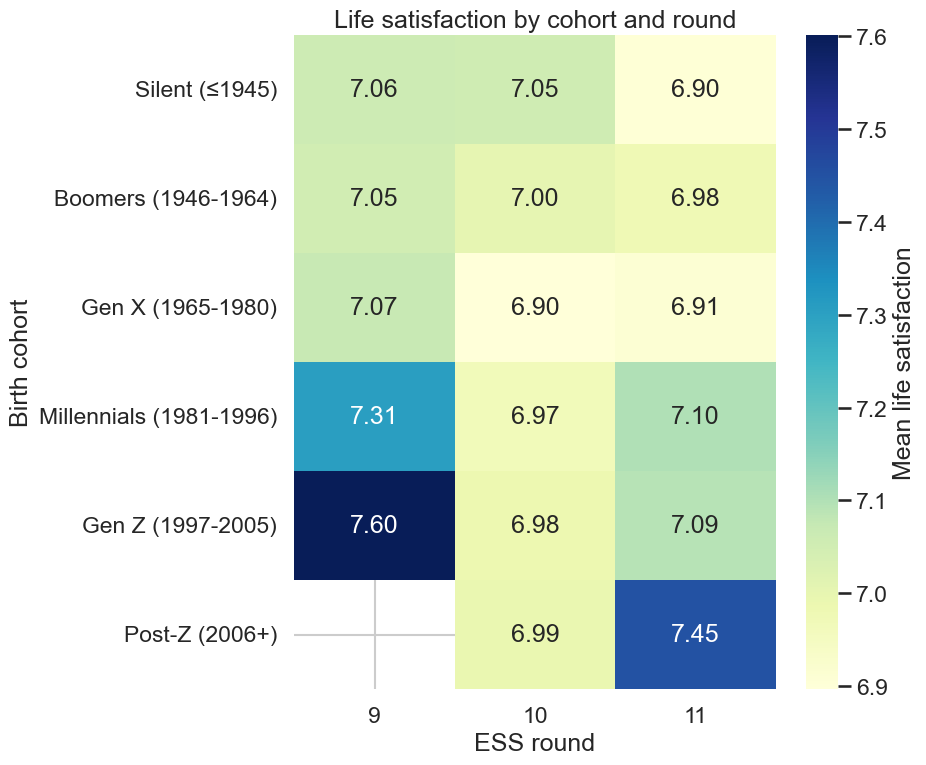

In [7]:
# Cohort gaps in life satisfaction

df = pd.read_csv("filtered_columns.csv")

df["stflife"]  = pd.to_numeric(df["stflife"],  errors="coerce")
df["anweight"] = pd.to_numeric(df["anweight"], errors="coerce")
df["essround"] = pd.to_numeric(df["essround"], errors="coerce").round().astype("Int64")

df["stflife"] = df["stflife"].mask(df["stflife"].isin([77, 88, 99]))
df = df.dropna(subset=["anweight", "stflife"])

bins   = [1900, 1945, 1964, 1980, 1996, 2005, 2100]
labels = ["Silent (≤1945)", "Boomers (1946-1964)", "Gen X (1965-1980)",
          "Millennials (1981-1996)", "Gen Z (1997-2005)", "Post-Z (2006+)"]

df["yrbrn"]  = pd.to_numeric(df["yrbrn"], errors="coerce")
df["cohort"] = pd.cut(df["yrbrn"], bins=bins, labels=labels, right=True)
df["cohort"] = pd.Categorical(df["cohort"], categories=labels, ordered=True)

def wmean(g):
    x = g["stflife"].to_numpy(float)
    w = g["anweight"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

agg = (df.groupby(["cohort", "essround"], observed=True)
        .apply(wmean).rename("stflife_mean").reset_index())

round_order = sorted(agg["essround"].dropna().unique())
heat = (agg.pivot(index="cohort", columns="essround", values="stflife_mean")
           .reindex(index=labels, columns=round_order))

sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(1.8*len(round_order)+4, 1.0*len(labels)+2))
ax = sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu",
                 cbar_kws={"label": "Mean life satisfaction"})
ax.set(xlabel="ESS round", ylabel="Birth cohort",
       title="Life satisfaction by cohort and round")
plt.tight_layout()
plt.show()

The heat map shows a pattern that shows how people of different ages change their behavior throughout different periods. The youngest groups show the highest results in Round 9. Gen Z averages about 7.60 and Millennials about 7.31, while older cohorts cluster near 7.05 to 7.07. The results show that all members of the group perform within a range of 6.90 to 7.05. The younger groups show a partial recovery in Round 11 because their average scores reach Millennials (7.10), Gen Z (7.09) and Post-Z (7.45). The lowest averages are for the Silent and Gen X cohorts near 6.90 to 6.91.

## Cohort gaps in institutional trust
*Across the ESS rounds, which birth cohorts have the highest and lowest average institutional trust?*



<positron-console-cell-8>:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


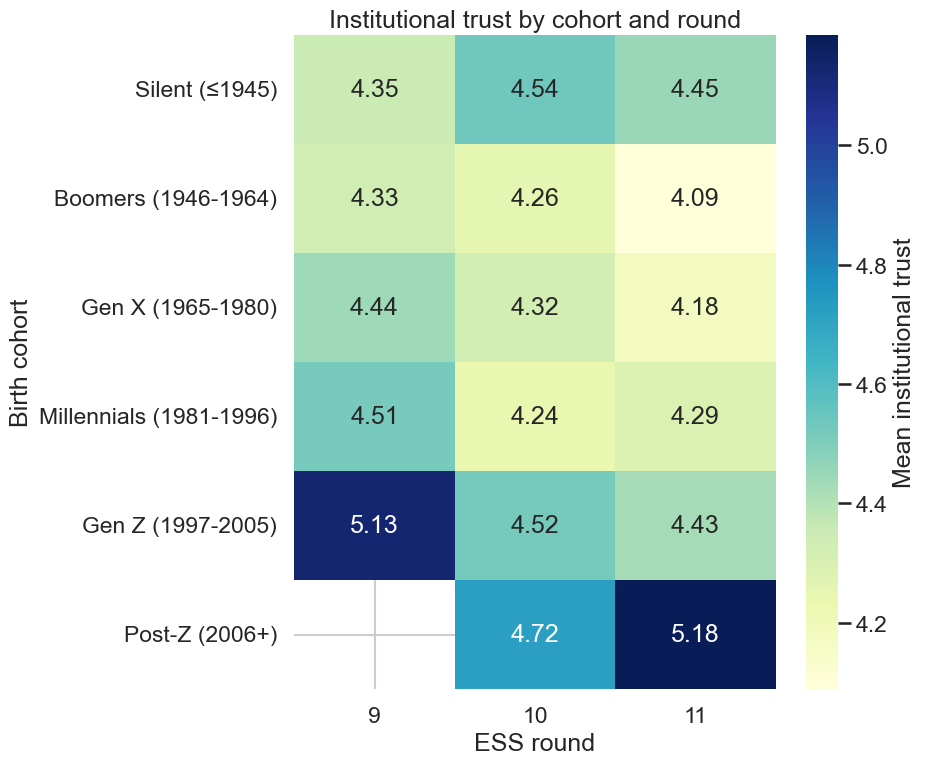

In [8]:
# Cohort gaps in institutional trust

df = pd.read_csv("filtered_columns.csv")

trust_vars = ["trstprl", "trstplt", "trstlgl"]
for v in trust_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce").mask(lambda s: s.isin([77, 88, 99]))

df["anweight"] = pd.to_numeric(df["anweight"], errors="coerce")
df["essround"] = pd.to_numeric(df["essround"], errors="coerce").round().astype("Int64")
df = df.dropna(subset=["anweight"])

df["trust_index"] = df[trust_vars].mean(axis=1)

bins   = [1900, 1945, 1964, 1980, 1996, 2005, 2100]
labels = ["Silent (≤1945)", "Boomers (1946-1964)", "Gen X (1965-1980)",
          "Millennials (1981-1996)", "Gen Z (1997-2005)", "Post-Z (2006+)"]

df["yrbrn"]  = pd.to_numeric(df["yrbrn"], errors="coerce")
df["cohort"] = pd.cut(df["yrbrn"], bins=bins, labels=labels, right=True)
df["cohort"] = pd.Categorical(df["cohort"], categories=labels, ordered=True)

def wmean_g(g):
    x = g["trust_index"].to_numpy(float)
    w = g["anweight"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

agg = (df.groupby(["cohort", "essround"], observed=True)
        .apply(wmean_g).rename("trust_mean").reset_index())

round_order = sorted(agg["essround"].dropna().unique())
heat = (agg.pivot(index="cohort", columns="essround", values="trust_mean")
           .reindex(index=labels, columns=round_order))

sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(1.8*len(round_order)+4, 1.0*len(labels)+2))
ax = sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu",
                 cbar_kws={"label": "Mean institutional trust"})
ax.set(xlabel="ESS round", ylabel="Birth cohort",
       title="Institutional trust by cohort and round")
plt.tight_layout()
plt.show()

The highest average trust across all rounds belongs to Gen Z which shows the most trust in Round 9 at approximately 5.13 and Post‑Z shows the most trust in Round 10 at approximately 4.72 and Post‑Z shows the most trust again in Round 11 at approximately 5.18. The lowest trust sits among Boomers and Gen X, in Round 9 Boomers are on 4.33; in Round 10 Millennials and Boomers are lowest (4.24 to 4.26); in Round 11 Boomers and Gen X are lowest (≈ 4.09–4.18). The testing results show small differences between groups in Round 10 which range between 0.4 and 0.5 points yet Rounds 9 and 11 show greater differences which reach 0.7 to 1.1 points.

## Distributional view
*How do the distributions of life satisfaction differ across cohorts and which cohorts appear most or least dispersed?*

<positron-console-cell-9>:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


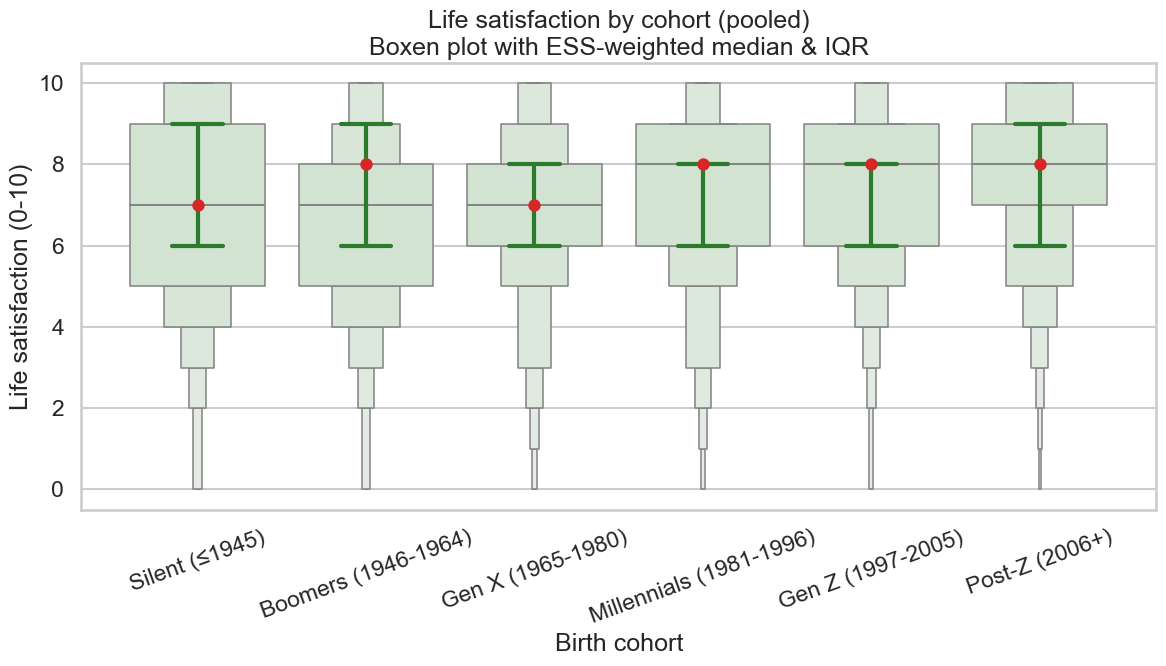

In [9]:
# Distributional view

df = pd.read_csv("filtered_columns.csv")
df["stflife"]  = pd.to_numeric(df["stflife"],  errors="coerce").mask(lambda s: s.isin([77,88,99]))
df["anweight"] = pd.to_numeric(df["anweight"], errors="coerce")
df["yrbrn"]    = pd.to_numeric(df["yrbrn"],    errors="coerce")
df = df.dropna(subset=["anweight", "stflife"])

bins   = [1900, 1945, 1964, 1980, 1996, 2005, 2100]
labels = ["Silent (≤1945)", "Boomers (1946-1964)", "Gen X (1965-1980)",
          "Millennials (1981-1996)", "Gen Z (1997-2005)", "Post-Z (2006+)"]
df["cohort"] = pd.cut(df["yrbrn"], bins=bins, labels=labels, right=True)
df = df.dropna(subset=["cohort"])
df["cohort"] = pd.Categorical(df["cohort"], categories=labels, ordered=True)

def wq(x, w, qs):
    x, w = np.asarray(x, float), np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not m.any(): return np.full(len(np.atleast_1d(qs)), np.nan)
    x, w = x[m], w[m]
    idx = np.argsort(x); x, w = x[idx], w[idx]
    cw = w.cumsum(); cw /= cw[-1]
    return np.interp(np.atleast_1d(qs), cw, x)

stats = (df.groupby("cohort", observed=True)
           .apply(lambda g: pd.Series(dict(q25=wq(g["stflife"], g["anweight"], .25),
                                           q50=wq(g["stflife"], g["anweight"], .50),
                                           q75=wq(g["stflife"], g["anweight"], .75))))
           .reindex(labels))

sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxenplot(data=df, x="cohort", y="stflife",
              order=labels, color="#cfe6cf", k_depth="proportion", ax=ax)

for i, coh in enumerate(labels):
    row = stats.loc[coh]
    if pd.notna(row["q50"]):
        ax.scatter(i, row["q50"], color="#d62728", s=55, zorder=3)
        ax.vlines(i, row["q25"], row["q75"], color="#2c7a2c", lw=3)
        ax.plot([i-0.15, i+0.15], [row["q25"], row["q25"]], color="#2c7a2c", lw=3)
        ax.plot([i-0.15, i+0.15], [row["q75"], row["q75"]], color="#2c7a2c", lw=3)

ax.set(xlabel="Birth cohort", ylabel="Life satisfaction (0-10)",
       title="Life satisfaction by cohort (pooled)\nBoxen plot with ESS-weighted median & IQR")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Across rounds, the weighted median life satisfaction increases toward the younger cohorts, roughly 6.9 for the Silent cohort, about 7.0 for Boomers and Gen X, and nearer 7.8 to 8.0 for Millennials, Gen Z, and Post‑Z. The interquartile range is widest for the Silent cohort (6.0 to 8.5), indicating the greatest heterogeneity, while Boomers and Gen X show the tightest IQRs (6.0 to 7.8), hence the least dispersion. Millennials and Gen Z have upper quartiles that push into the high values near 8.5 to 9, with lower quartiles still around 6, suggesting moderately wide spreads concentrated toward the top of the scale.